In [ ]:
import os
import pandas as pd

# ===================================
# נתיבים
# ===================================
dataset_split_path = '/content/drive/MyDrive/dataset_split'
real_data_path = '/content/drive/MyDrive/selected_clips_hebrew'

audio_extensions = ('.wav', '.mp3', '.m4a', '.flac', '.ogg')
data = []

def get_compression_type(filename):
    ext = os.path.splitext(filename)[1].lower()

    if ext == '.wav':
        return 'wav_uncompressed'
    elif ext == '.mp3':
        return 'mp3'
    elif ext == '.m4a':
        return 'm4a'
    elif ext == '.flac':
        return 'flac'
    elif ext == '.ogg':
        return 'ogg'
    else:
        return 'other'

# ===================================
# 1. רק elevenlabs_fake מתוך train/test
# ===================================
if not os.path.exists(dataset_split_path):
    print(f"הנתיב {dataset_split_path} לא קיים")
else:
    for split in ['train', 'test']:
        elevenlabs_path = os.path.join(dataset_split_path, split, 'fake', 'elevenlabs_fake')

        if not os.path.exists(elevenlabs_path):
            print(f"לא נמצאה התיקייה: {elevenlabs_path}")
            continue

        for root, dirs, files in os.walk(elevenlabs_path):
            for filename in files:
                if filename.lower().endswith(audio_extensions):
                    recording_id = os.path.splitext(filename)[0]
                    compression_type = get_compression_type(filename)

                    data.append({
                        'recording_id': recording_id,
                        'compression_type': compression_type,
                        'source_dataset': 'custom_elevenlabs',
                        'label': 'spoof',
                        'attack_type': 'elevenlabs'
                    })

# ===================================
# 2. הקלטות אמיתיות מתוך selected_hebrew
# ===================================
if not os.path.exists(real_data_path):
    print(f"הנתיב {real_data_path} לא קיים")
else:
    for root, dirs, files in os.walk(real_data_path):
        for filename in files:
            if filename.lower().endswith(audio_extensions):
                recording_id = os.path.splitext(filename)[0]
                compression_type = get_compression_type(filename)

                data.append({
                    'recording_id': recording_id,
                    'compression_type': compression_type,
                    'source_dataset': 'selected_hebrew',
                    'label': 'bonafide',
                    'attack_type': 'bonafide'
                })

# ===================================
# 3. שמירה ל-CSV
# ===================================
if data:
    df_custom = pd.DataFrame(data)

    df_custom = df_custom[
        ['recording_id', 'compression_type', 'source_dataset', 'label', 'attack_type']
    ]

    output_csv = '/content/elevenlabs_and_selected_hebrew.csv'
    df_custom.to_csv(output_csv, index=False, encoding='utf-8-sig')

    print(f"נוצר קובץ CSV עם {len(df_custom)} רשומות")
    print(f"הקובץ נשמר כאן: {output_csv}")

    print("\nדוגמה ל-10 שורות:")
    display(df_custom.sample(min(10, len(df_custom))))

    print("\nספירה לפי label:")
    print(df_custom['label'].value_counts())

    print("\nספירה לפי source_dataset:")
    print(df_custom['source_dataset'].value_counts())
else:
    print("לא נמצאו קבצי אודיו.")

נוצר קובץ CSV עם 2216 רשומות
הקובץ נשמר כאן: /content/elevenlabs_and_selected_hebrew.csv

דוגמה ל-10 שורות:


,recording_id,compression_type,source_dataset,label,attack_type
1397,common_voice_he_38146695,mp3,selected_hebrew,bonafide,bonafide
1052,fake_common_voice_he_39960253,mp3,custom_elevenlabs,spoof,elevenlabs
1218,common_voice_he_39960273,mp3,selected_hebrew,bonafide,bonafide
660,fake_common_voice_he_39658869,mp3,custom_elevenlabs,spoof,elevenlabs
533,fake_common_voice_he_39522892,mp3,custom_elevenlabs,spoof,elevenlabs
38,fake_common_voice_he_38094128,mp3,custom_elevenlabs,spoof,elevenlabs
1833,common_voice_he_39553824,mp3,selected_hebrew,bonafide,bonafide
1015,fake_common_voice_he_39897646,mp3,custom_elevenlabs,spoof,elevenlabs
463,fake_common_voice_he_41616729,mp3,custom_elevenlabs,spoof,elevenlabs
1056,fake_common_voice_he_39211668,mp3,custom_elevenlabs,spoof,elevenlabs



ספירה לפי label:
label
spoof       1108
bonafide    1108
Name: count, dtype: int64

ספירה לפי source_dataset:
source_dataset
custom_elevenlabs    1108
selected_hebrew      1108
Name: count, dtype: int64


In [ ]:
import sqlite3
import pandas as pd
import os

# ==============================
# נתיבים לקבצי ה-CSV
# ==============================
balanced_csv = '/content/balanced_dataset.csv'
custom_csv = '/content/elevenlabs_and_selected_hebrew.csv'
db_name = '/content/final_voice_project.db'

# ==============================
# 1. טעינת שתי הטבלאות
# ==============================
df1 = pd.read_csv(balanced_csv)
df2 = pd.read_csv(custom_csv)

# איחוד לטבלה אחת
df_all = pd.concat([df1, df2], ignore_index=True)

# ניקוי בסיסי
df_all = df_all.drop_duplicates(subset=['recording_id'])
df_all = df_all[['recording_id', 'compression_type', 'source_dataset', 'label', 'attack_type']]

print("מספר רשומות לאחר איחוד:", len(df_all))
display(df_all.head())

# ==============================
# 2. יצירת מסד הנתונים
# ==============================
if os.path.exists(db_name):
    os.remove(db_name)

conn = sqlite3.connect(db_name)
cursor = conn.cursor()
cursor.execute("PRAGMA foreign_keys = ON;")

cursor.executescript("""
CREATE TABLE CompressionTypes (
    compression_id INTEGER PRIMARY KEY AUTOINCREMENT,
    compression_type VARCHAR(50) UNIQUE
);

CREATE TABLE SourceDatasets (
    dataset_id INTEGER PRIMARY KEY AUTOINCREMENT,
    source_dataset VARCHAR(50) UNIQUE
);

CREATE TABLE Labels (
    label_id INTEGER PRIMARY KEY AUTOINCREMENT,
    label VARCHAR(50) UNIQUE
);

CREATE TABLE AttackTypes (
    attack_id INTEGER PRIMARY KEY AUTOINCREMENT,
    attack_type VARCHAR(100) UNIQUE
);

CREATE TABLE Recordings (
    recording_id VARCHAR(150) PRIMARY KEY,
    compression_id INTEGER NOT NULL,
    dataset_id INTEGER NOT NULL,
    label_id INTEGER NOT NULL,
    attack_id INTEGER NOT NULL,
    FOREIGN KEY (compression_id) REFERENCES CompressionTypes(compression_id),
    FOREIGN KEY (dataset_id) REFERENCES SourceDatasets(dataset_id),
    FOREIGN KEY (label_id) REFERENCES Labels(label_id),
    FOREIGN KEY (attack_id) REFERENCES AttackTypes(attack_id)
);
""")

# ==============================
# 3. הכנסת ערכים לטבלאות המימד
# ==============================
compression_values = sorted(df_all['compression_type'].dropna().astype(str).unique())
dataset_values = sorted(df_all['source_dataset'].dropna().astype(str).unique())
label_values = sorted(df_all['label'].dropna().astype(str).unique())
attack_values = sorted(df_all['attack_type'].dropna().astype(str).unique())

cursor.executemany(
    "INSERT INTO CompressionTypes (compression_type) VALUES (?)",
    [(x,) for x in compression_values]
)

cursor.executemany(
    "INSERT INTO SourceDatasets (source_dataset) VALUES (?)",
    [(x,) for x in dataset_values]
)

cursor.executemany(
    "INSERT INTO Labels (label) VALUES (?)",
    [(x,) for x in label_values]
)

cursor.executemany(
    "INSERT INTO AttackTypes (attack_type) VALUES (?)",
    [(x,) for x in attack_values]
)

conn.commit()

# ==============================
# 4. בניית מילוני המרה לערכי ID
# ==============================
compression_map = {
    row[1]: row[0]
    for row in cursor.execute("SELECT compression_id, compression_type FROM CompressionTypes").fetchall()
}

dataset_map = {
    row[1]: row[0]
    for row in cursor.execute("SELECT dataset_id, source_dataset FROM SourceDatasets").fetchall()
}

label_map = {
    row[1]: row[0]
    for row in cursor.execute("SELECT label_id, label FROM Labels").fetchall()
}

attack_map = {
    row[1]: row[0]
    for row in cursor.execute("SELECT attack_id, attack_type FROM AttackTypes").fetchall()
}

# ==============================
# 5. הכנסת הנתונים לטבלת Recordings
# ==============================
recordings_rows = []

for _, row in df_all.iterrows():
    recordings_rows.append((
        str(row['recording_id']),
        compression_map[str(row['compression_type'])],
        dataset_map[str(row['source_dataset'])],
        label_map[str(row['label'])],
        attack_map[str(row['attack_type'])]
    ))

cursor.executemany("""
INSERT INTO Recordings (
    recording_id,
    compression_id,
    dataset_id,
    label_id,
    attack_id
)
VALUES (?, ?, ?, ?, ?)
""", recordings_rows)

conn.commit()

# ==============================
# 6. בדיקות
# ==============================
print("המסד נוצר בהצלחה:", db_name)

print("\nמספר רשומות בכל טבלה:")
for table in ['CompressionTypes', 'SourceDatasets', 'Labels', 'AttackTypes', 'Recordings']:
    count = cursor.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"{table}: {count}")

print("\nדוגמת JOIN מהמסד:")
query = """
SELECT
    r.recording_id,
    c.compression_type,
    s.source_dataset,
    l.label,
    a.attack_type
FROM Recordings r
JOIN CompressionTypes c ON r.compression_id = c.compression_id
JOIN SourceDatasets s ON r.dataset_id = s.dataset_id
JOIN Labels l ON r.label_id = l.label_id
JOIN AttackTypes a ON r.attack_id = a.attack_id
LIMIT 10;
"""

result_df = pd.read_sql_query(query, conn)
display(result_df)

conn.close()

מספר רשומות לאחר איחוד: 13286


,recording_id,compression_type,source_dataset,label,attack_type
0,DF_E_2300589,low_mp3,vcc2018,spoof,traditional_vocoder
1,DF_E_2094885,oggm4a,asvspoof,spoof,neural_vocoder_autoregressive
2,DF_E_2319419,high_ogg,vcc2020,spoof,neural_vocoder_nonautoregressive
3,DF_E_2386051,oggm4a,vcc2020,spoof,neural_vocoder_autoregressive
4,DF_E_2141966,low_mp3,asvspoof,spoof,neural_vocoder_autoregressive


המסד נוצר בהצלחה: /content/final_voice_project.db

מספר רשומות בכל טבלה:
CompressionTypes: 10
SourceDatasets: 5
Labels: 2
AttackTypes: 7
Recordings: 13286

דוגמת JOIN מהמסד:


,recording_id,compression_type,source_dataset,label,attack_type
0,DF_E_2300589,low_mp3,vcc2018,spoof,traditional_vocoder
1,DF_E_2094885,oggm4a,asvspoof,spoof,neural_vocoder_autoregressive
2,DF_E_2319419,high_ogg,vcc2020,spoof,neural_vocoder_nonautoregressive
3,DF_E_2386051,oggm4a,vcc2020,spoof,neural_vocoder_autoregressive
4,DF_E_2141966,low_mp3,asvspoof,spoof,neural_vocoder_autoregressive
5,DF_E_2104978,mp3m4a,vcc2018,bonafide,bonafide
6,DF_E_2470402,high_ogg,vcc2018,spoof,traditional_vocoder
7,DF_E_2000676,low_ogg,vcc2018,bonafide,bonafide
8,DF_E_2371707,low_m4a,vcc2020,spoof,unknown
9,DF_E_2162213,high_ogg,vcc2020,bonafide,bonafide


In [ ]:
import os
import sqlite3

# ==============================
# נתיבים
# ==============================
db_name = '/content/final_voice_project.db'
base_path = '/content/drive/MyDrive/dataset_split'

audio_extensions = ('.wav', '.mp3', '.m4a', '.flac', '.ogg')

# ==============================
# חיבור למסד
# ==============================
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# ==============================
# 1. הוספת עמודת file_path אם לא קיימת
# ==============================
cursor.execute("PRAGMA table_info(Recordings);")
columns = [col[1] for col in cursor.fetchall()]

if 'file_path' not in columns:
    cursor.execute("ALTER TABLE Recordings ADD COLUMN file_path TEXT;")
    conn.commit()
    print("נוספה עמודת file_path")
else:
    print("העמודה file_path כבר קיימת")

# ==============================
# 2. בניית מילון: recording_id -> path
# ==============================
path_map = {}

for split in ['train', 'test']:
    split_path = os.path.join(base_path, split)
    if not os.path.exists(split_path):
        print(f"לא נמצאה תיקייה: {split_path}")
        continue

    for root, dirs, files in os.walk(split_path):
        for filename in files:
            if filename.lower().endswith(audio_extensions):
                recording_id = os.path.splitext(filename)[0]
                full_path = os.path.join(root, filename)

                # אם יש כפילות בשם קובץ, הראשון יישמר
                if recording_id not in path_map:
                    path_map[recording_id] = full_path

print(f"נמצאו {len(path_map)} קבצים עם נתיבים")

# ==============================
# 3. עדכון הנתיבים במסד
# ==============================
updated_count = 0

for recording_id, full_path in path_map.items():
    cursor.execute("""
        UPDATE Recordings
        SET file_path = ?
        WHERE recording_id = ?
    """, (full_path, recording_id))

    updated_count += cursor.rowcount

conn.commit()

print(f"עודכנו {updated_count} רשומות במסד עם file_path")

# ==============================
# 4. בדיקות
# ==============================
cursor.execute("""
    SELECT COUNT(*)
    FROM Recordings
    WHERE file_path IS NOT NULL
""")
filled_count = cursor.fetchone()[0]

cursor.execute("""
    SELECT COUNT(*)
    FROM Recordings
    WHERE file_path IS NULL
""")
null_count = cursor.fetchone()[0]

print(f"רשומות עם נתיב: {filled_count}")
print(f"רשומות בלי נתיב: {null_count}")

import pandas as pd

# ==============================
# 5. הצגת טבלה מלאה כמו CSV + נתיב
# ==============================
query = """
SELECT
    r.recording_id,
    c.compression_type,
    s.source_dataset,
    l.label,
    a.attack_type,
    r.file_path
FROM Recordings r
JOIN CompressionTypes c ON r.compression_id = c.compression_id
JOIN SourceDatasets s ON r.dataset_id = s.dataset_id
JOIN Labels l ON r.label_id = l.label_id
JOIN AttackTypes a ON r.attack_id = a.attack_id
LIMIT 10;
"""

df_result = pd.read_sql_query(query, conn)

display(df_result)

העמודה file_path כבר קיימת
נמצאו 13286 קבצים עם נתיבים
עודכנו 13286 רשומות במסד עם file_path
רשומות עם נתיב: 13286
רשומות בלי נתיב: 0


,recording_id,compression_type,source_dataset,label,attack_type,file_path
0,DF_E_2300589,low_mp3,vcc2018,spoof,traditional_vocoder,/content/drive/MyDrive/dataset_split/train/fak...
1,DF_E_2094885,oggm4a,asvspoof,spoof,neural_vocoder_autoregressive,/content/drive/MyDrive/dataset_split/train/fak...
2,DF_E_2319419,high_ogg,vcc2020,spoof,neural_vocoder_nonautoregressive,/content/drive/MyDrive/dataset_split/train/fak...
3,DF_E_2386051,oggm4a,vcc2020,spoof,neural_vocoder_autoregressive,/content/drive/MyDrive/dataset_split/test/fake...
4,DF_E_2141966,low_mp3,asvspoof,spoof,neural_vocoder_autoregressive,/content/drive/MyDrive/dataset_split/train/fak...
5,DF_E_2104978,mp3m4a,vcc2018,bonafide,bonafide,/content/drive/MyDrive/dataset_split/train/rea...
6,DF_E_2470402,high_ogg,vcc2018,spoof,traditional_vocoder,/content/drive/MyDrive/dataset_split/test/fake...
7,DF_E_2000676,low_ogg,vcc2018,bonafide,bonafide,/content/drive/MyDrive/dataset_split/train/rea...
8,DF_E_2371707,low_m4a,vcc2020,spoof,unknown,/content/drive/MyDrive/dataset_split/train/fak...
9,DF_E_2162213,high_ogg,vcc2020,bonafide,bonafide,/content/drive/MyDrive/dataset_split/train/rea...


קורא את נתוני הטבלאות...
תרשים ה-ERD נוצר בהצלחה!


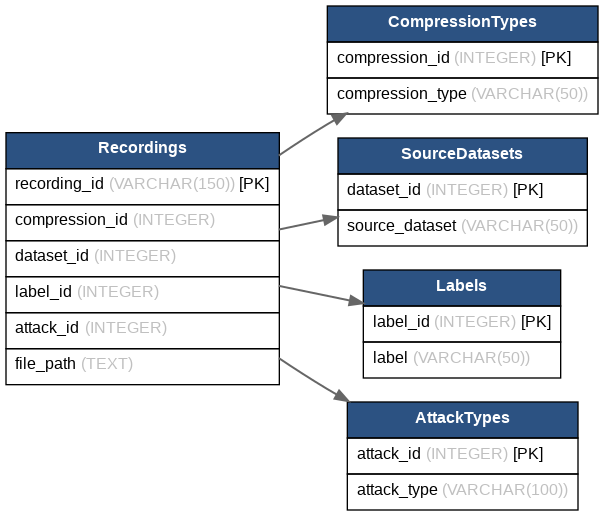

In [ ]:
import sqlite3
from graphviz import Digraph
from IPython.display import Image, display

# --- שלב 3: יצירת תרשים ERD ויזואלי ישירות ממסד הנתונים ---
db_name = 'final_voice_project.db'
output_name = 'my_final_erd'

def generate_erd(database_name, output_filename):
    print("קורא את נתוני הטבלאות...")
    conn = sqlite3.connect(database_name)
    cursor = conn.cursor()

    # הגדרת עיצוב התרשים
    dot = Digraph(comment='Database ERD', format='png')
    dot.attr(rankdir='LR', size='10,8')  # כיוון משמאל לימין
    dot.attr('node', shape='plain', fontname='Helvetica', fontsize='12')   # שונה מ-record ל-plain
    dot.attr('edge', color='#666666', penwidth='1.5')

    # שליפת כל הטבלאות ממסד הנתונים
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';")
    tables = cursor.fetchall()

    for table in tables:
        table_name = table[0]

        # שליפת העמודות לכל טבלה
        cursor.execute(f"PRAGMA table_info({table_name});")
        columns = cursor.fetchall()

        # בניית קוביות הטבלה
        label = '<<TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" CELLPADDING="6">'
        label += f'<TR><TD BGCOLOR="#2c5282"><FONT COLOR="white"><B>{table_name}</B></FONT></TD></TR>'

        for col in columns:
            col_name = col[1]
            col_type = col[2]
            is_pk = col[5]

            # סימון מפתח ראשי (Primary Key)
            pk_mark = " [PK]" if is_pk else ""
            label += f'<TR><TD ALIGN="LEFT">{col_name} <FONT COLOR="gray">({col_type})</FONT>{pk_mark}</TD></TR>'

        label += '</TABLE>>'
        dot.node(table_name, label=label)   # הורדתי shape='none', margin='0'

        # שליפת קשרים (Foreign Keys) ומתיחת חצים
        cursor.execute(f"PRAGMA foreign_key_list({table_name});")
        fks = cursor.fetchall()
        for fk in fks:
            to_table = fk[2]  # הטבלה אליה הקשר מצביע
            dot.edge(table_name, to_table)

    # שמירת התמונה
    dot.render(output_filename, cleanup=True)
    conn.close()
    print("תרשים ה-ERD נוצר בהצלחה!")

# הפעלת הפונקציה והצגת התמונה
generate_erd(db_name, output_name)
display(Image(filename=f"{output_name}.png"))